In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

In [3]:
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

In [4]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [6]:
df_us = df[df['job_country'] == 'United States'].copy()
df_us['job_posted_month'] = df_us.job_posted_date.dt.strftime('%B')

In [7]:
df_us_month = df_us.pivot_table(
    index= 'job_posted_month',
    columns= 'job_title_short',
    aggfunc='size'
)
df_us_month.reset_index(inplace=True)
df_us_month['month_num'] = pd.to_datetime(df_us_month['job_posted_month'] , format='%B').dt.month 
df_us_month.sort_values(by='month_num' , inplace=True)
df_us_month.set_index('job_posted_month', inplace=True)

In [8]:
top3 = df_us.value_counts('job_title_short').head(3)
df_us_month = df_us_month[top3.index.tolist()]

In [11]:
df_us_software = pd.read_csv("https://lukeb.co/software_csv" , index_col='job_posted_month')

In [13]:
df_us_merge = df_us_month.merge(df_us_software , on='job_posted_month')

In [15]:
top5 = df_us_merge.sum().sort_values(ascending=False).head().index.to_list()

<Axes: xlabel='job_posted_month'>

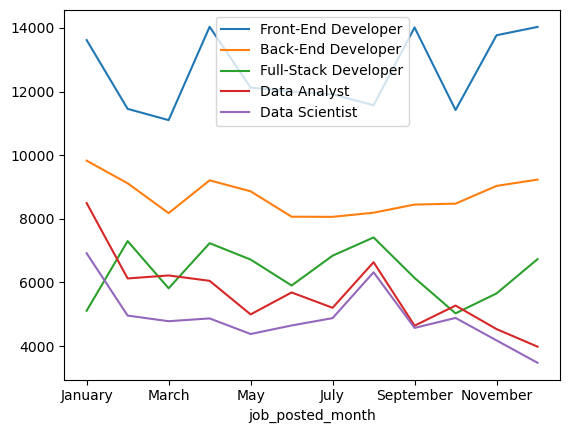

In [16]:
df_us_merge[top5].plot(kind='line')